# Imports and setup

In [56]:
import numpy as np 
import json
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor , RandomForestClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error, hamming_loss, log_loss, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from model_predictor import softmax
import matplotlib.pyplot as plt

# Import the dataset
X_train = np.loadtxt("evaluation_data/train_set_x.csv", delimiter=",")
_y_train = np.loadtxt("evaluation_data/train_set_y.csv", delimiter=",")
y_train = _y_train / (np.sum(_y_train, axis=1).reshape(-1,1) + 0.000_001) # Transform output into probability distribution
# y_train = _y_train

X_test  = np.loadtxt("evaluation_data/test_set_x.csv", delimiter=",")
_y_test  = np.loadtxt("evaluation_data/test_set_y.csv", delimiter=",")
y_test = _y_test / (np.sum(_y_test, axis=1).reshape(-1,1) +0.000_001)# Transform output into probability distribution

X_val   = np.loadtxt("evaluation_data/eval_set_x.csv", delimiter=",")
_y_val   = np.loadtxt("evaluation_data/eval_set_y.csv", delimiter=",")
y_val =  _y_val / (np.sum(_y_val, axis=1).reshape(-1,1) +0.000_0001)# Transform output into probability distribution




# Returns the MLP given its weights in a json file.
def get_MLP(path="backend/recommendation/model.json"):
    f = open(path, "r")
    data= json.load(f)
    f.close()

    model = MLPClassifier(max_iter=10_000, hidden_layer_sizes= data["hidden_layers"], random_state=1, activation='logistic',solver='adam')
    # Just used to handle assigning dimensions to the neural network, not for actual training
    temp_X = np.zeros(shape=(2, data["n_features_in"] )) 
    temp_y = np.zeros(shape=(2, data["n_outputs"]))
    model.fit(temp_X, temp_y)

    model.coefs_ = [np.array(w) for w in data["network"]["weights"] ] # convert back to numpy arrays
    model.intercepts_ = [np.array(b) for b in data["network"]["biases"] ]

    return model

In [57]:
# # Metrics
# def get_tp(preds, truth, c):
#     return np.sum((preds==truth)[truth == c])

# def get_tn(preds, truth, c):
#     return np.sum((preds==truth)[truth != c])

# def get_fp(preds, truth, c):
#     return np.sum((preds==c)[truth!=c])

# def get_fn(preds, truth, c):
#     return np.sum((preds!=c)[truth==c])

# # Finds the precision for class c
# def precision(preds, truth, c):
#     true_positives  =  get_tp(preds, truth, c)
#     false_positives =  get_fp(preds, truth, c)
#     # print(false_positives)
#     return true_positives / (true_positives + false_positives)

# def recall(preds, truth, c):
#    tp = get_tp(preds, truth,c)
#    fn = get_fn(preds, truth,c)
#    # print(fn)
#    return tp / (tp + fn)



# # The average recall across all classes
# def avr_recall(preds, truth):
#    recalls = []
#    for c in np.unique(truth):
#        recalls.append(recall(preds, truth, c))
#    return np.mean(recalls)

# # The average precision across all classes
# def avr_precision(preds, truth):
#     precs = []
#     for c in np.unique(truth):
#         precs.append(precision(preds, truth, c))
#     return np.mean(precs)

# # The average f1 across all classes
# def avr_f1(preds, truth):
#     r1 = []
#     for c in np.unique(truth):
#         p = precision(preds, truth, c); r = recall(preds,truth,c)
#         f1 = 2. * (p * r) / (p + r)
#         r1.append(f1)
#     return np.mean(f1)


# def accuracy(discrete_pred, y_test):
#     return np.sum(discrete_pred == y_test) / y_test.shape[0]

SEED = 42

def seed_everything(seed=SEED):
    np.random.seed(SEED) # set seed for numpy for reproducible results



# def f1(preds, trugh)

mae= 0.044715444850949485


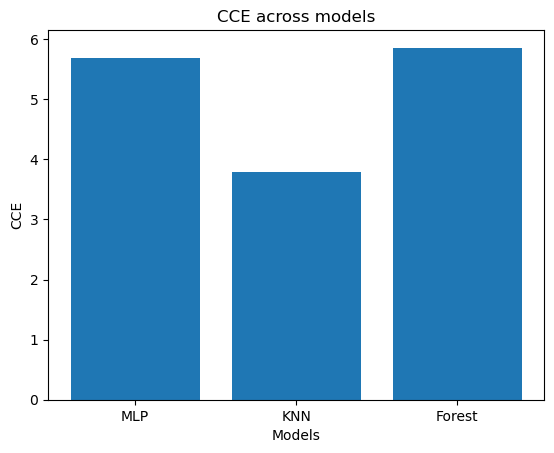

In [63]:
# Load the pre-made model

# 1) Test the pre-trained Neural Network
mlp = get_MLP("model.json")

predictions = mlp.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print("mae=", mae)


# b) Train the KNN classifier
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# The KNN must predict a probability distribution, so this function just predicts with KNN, then adds a softmax layer at the end.
# Just a normal probability seems to work better though.
# Kinda needed for the CCE metric, and since this is implicitly what the actual working model would do at the end.
# Ugh I don't like this, feel free to change this to something better
TEMP = 5.0
def softmax_predict(model, X_test, temperature=5.0):
    pred = model.predict(X_test)
    # _pred =  pred / (np.sum(pred, axis=1).reshape(-1,1) + 0.000_001); #s
    _pred = softmax(pred,temperature)
    return _pred


knn = KNeighborsRegressor(n_neighbors=5, algorithm="brute", weights="uniform")
knn.fit(X_train, y_train)


# print("pred=", pred)
# print("mae=", mean_absolute_error(y_test, pred))
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# c) Train the Random forest classifier
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
forest =  RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)

# Takes the top 5 most likely classes, and sets it to 1, otherwise 0. Lets you do things like accuracy.
def topk_predict(pred, k=5):
    new_pred = np.zeros(shape=pred.shape)
    for i in range(pred.shape[0]):
        row = pred[i]
        top5 = np.argsort(row)[-k : ]
        row = np.zeros(shape=row.shape)
        row[top5] = 1
        new_pred[i] = row 
    return new_pred



#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

def cce(y_test: np.ndarray, pred: np.ndarray):
    epsilon = 0.0001
    _pred = np.clip(pred, a_min=epsilon, a_max=1.0)
    return - np.mean( np.sum( y_test * np.log(_pred), axis=1))

# 2) Get bar charts for a given metric
def metric_mapper(_metric: str):
    metric_map = {"CCE": cce, "MAE": mean_absolute_error, "MSE": mean_squared_error, "HAM": categorical_hamming_loss, "ACC": categorical_accuracy} #  "PREC": avr_precision, "REC": avr_recall, "F1": avr_f1}
    metric = metric_map[_metric.upper()]    
    return metric
 

#* ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Categorical stuff
# # Just guesses the most likely hobby
# def categorical_predict(model, X_test):
#     # 1) Encode X_test back into binary again
#     pred = np.argmax( model.predict(X_test), axis=1 ) # Guess the most likely hobby
#     return pred


# # Encodes the labels to be binary (which is what it was originally)
# def categorical_encode(y_test):
#     return (y_test > 0.000_001).astype( np.int8)


# Fraction of labels that are incorrectly predicted
def categorical_hamming_loss(pred_prob, y_test_prob):
    y_test = (y_test_prob > 1e-6).astype(np.int8)
    pred = topk_predict(pred_prob)

    return hamming_loss(y_test, pred)


# ASSUMES y_test is categorically encoded already
# Gives the probability that the at least one of the k-highest voted hobby is actually one of the users hobbies.
def categorical_accuracy(pred_prob, y_test_prob, k=5):
    y_test =  (y_test_prob > 0.000_001).astype( np.int8)
    pred =  topk_predict(pred_prob, k=k)

    args_y    = [set(np.where(row == 1)[0]) for row in y_test]
    args_pred =  [set(np.where(row == 1)[0]) for row in pred]

    ncorrect = 0
    total = len(pred)
    for i in range(len(pred)):
        correct = args_pred[i].intersection(args_y[i])
        if len(correct) > 0:
            ncorrect += len(correct) / (len(args_y[i])+ 0.000_001)
    return ncorrect / total
#* ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
pred = knn.predict(X_test) 


# metric in ["CCE", "ACC", "MAE", "MSE"]
def bar_charts(models: list, _metric: str, X_test, y_test, plot_barchart=True):
    # metric_map = {"CCE": log_loss, "MAE": mean_absolute_error, "ACC": accuracy, "PREC": avr_precision, "REC": avr_recall, "F1": avr_f1}
    # metric = metric_map[_metric.upper()]
    metric = metric_mapper(_metric)


    metrics = []; model_names = []
    for model_name, model in models: 
        _pred = model.predict(X_test) ; #softmax_predict(model, X_test)
        _y_test = y_test

        error = metric(_y_test, _pred)
        model_names.append(model_name); metrics.append( error ) 

    # Plot results
    if plot_barchart:
        plt.bar(model_names, metrics)
        plt.title(f"{_metric} across models")
        plt.xlabel("Models")
        plt.ylabel(_metric)
        plt.show()
    
    return model_names, metrics



models = [("MLP", mlp), ("KNN", knn), ("Forest", forest) ]
name, metrics = bar_charts(models, "CCE", X_test, y_test)

# Cross validation box plots

model: MLP
scores= [0.42499992 0.4999999  0.37499993 0.44999991 0.59999988]
model: KNN
scores= [0.4999999  0.54999989 0.32499994 0.47499991 0.59999988]
model: Forest
scores= [0.42499992 0.39999992 0.39999992 0.5249999  0.62499988]


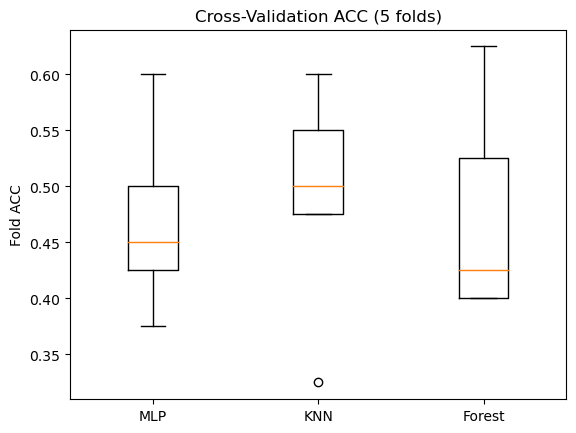

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'max_error', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_root_mean_squared_error', 'normalized_mutual_info_score', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'roc_auc', 'roc_auc_ovo', 'roc_auc_ovo_weighted', 'roc_auc_ovr', 'roc_auc_ovr_weighted', 'top_k_accuracy', 

In [59]:
import sklearn

# It cross_val_score needs it in a different format to be awkward
# def cross_val_mapper(model, X_test, y_test, _metric="ACC"):
#     metric = metric_mapper(_metric)
#     if _metric == "CCE" or _metric == "MAE": 
#         _pred = softmax_predict(model, X_test)
#     else:  
#         _pred = topk_predict( softmax_predict(model, X_test) )
#     return metric(_pred, y_test)

# def accuracy_(model, X_test, y_test):
#     preds = topk_predict( softmax_predict(model, X_test) )
#     return accuracy(preds, y_test)

def accuracy_(model, X_test, y_test):
    preds = model.predict(X_test)
    return categorical_accuracy(preds, y_test)



# nfolds=12 looks nicer but takes a while, because MLP is pretty slow (for me at least)
def cv_box_plot(models, X_train, y_train, metric="ACC", nfolds=3, show_plot=True):
    model_names = [x[0] for x in models]
    values = []
    
    _y_train = topk_predict(y_train) if metric == "ACC" else y_train


    for model_name, model in models:
        print("model:", model_name)
        cv_scores = cross_val_score(model, X_train, _y_train, cv=nfolds, scoring=accuracy_)
        print("scores=", cv_scores)
        values.append(  cv_scores )

    if show_plot:
        plt.boxplot(values, labels= model_names )
        plt.title(f"Cross-Validation {metric} ({nfolds} folds)")
        plt.ylabel(f"Fold {metric}")
        plt.show()

    return values 

cv_box_plot(models, X_train, y_train, nfolds=5)
print( sklearn.metrics.get_scorer_names() )


# Table summary of all the metrics

In [60]:
import pandas as pd 


metrics = ["Model", "CCE", "MAE", "MSE", "ACC", "HAM"] ; actual_metrics = metrics[1:]
n = len(metrics); n_models = len(models); zero =  [0 for _ in range(n_models)]
table =  pd.DataFrame( dict([(m,zero) for m in metrics ]) ) 
table["Model"] = [m[0] for m in models]

for metric in actual_metrics:
    name, results = bar_charts(models, metric, X_test, y_test, plot_barchart=False)
    table[metric] = results
table

# TODO: Ugh there's no way I did the accuracy and those kinda ones correct, the results should be much worse


,Model,CCE,MAE,MSE,ACC,HAM
0,MLP,5.679706,0.044715,0.039024,0.283333,0.136585
1,KNN,3.794214,0.042138,0.017787,0.245822,0.275610
2,Forest,5.857374,0.043577,0.019156,0.141722,0.300000


# T-test
p= 0.0000071 < 0.05 so there is sufficient evidence to reject the null hypothesis\
I.e it is worse than the baseline, oof

[6.0222844611968664, 7.125430916698926, 6.754675332125596, 8.735277817415145, 7.4256339085289, 7.609469593356052, 7.001648599803643, 6.204397650853103, 7.050875057817205, 8.327595697946744]
[5.2654248410865705, 5.539122487946704, 4.753873314197537, 4.5482899324318335, 5.120149861492267, 4.714825703185704, 5.257291952629017, 4.807284959006834, 4.09458421438224, 6.736005922441766]
T-Test results:  Ttest_relResult(statistic=6.888934561857613, pvalue=7.154771180403414e-05)
cr= 1.3830287383964925


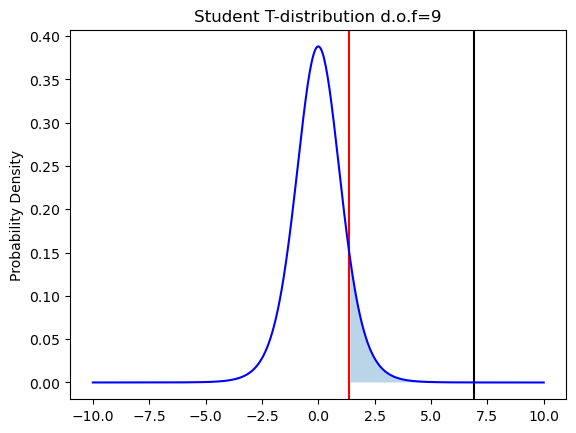

In [61]:
import scipy.stats as stats
from scipy.stats import t
from sklearn.model_selection import KFold

# Honestly we kind of want to show that it is not statistically significant lol or else we clearly have done something wrong.
mean_output =  np.sum(y_train, axis=0) / y_train.shape[0]
baseline = mean_output


# Generates a set of cce scores via kfolds.
def kfold_dataset(model, X, y, is_baseline=False):
    kf = KFold(10)

    results = []
    for (train_idx, test_idx) in kf.split(X):
        _X_train = X[train_idx]; _y_train = y[train_idx]
        _X_test = X[test_idx]; _y_test = y[test_idx]
        if is_baseline: 
            mean_output =  np.sum(_y_train, axis=0) / _y_train.shape[0]
            pred = mean_output
        else:
            model.fit(_X_train, _y_train) # we don't need to scale here 
            pred = model.predict(_X_test)

        error = cce(_y_test, pred)
        results.append(error)

    return results 



# Generates a set of cce scores via kfolds.
# Instead of retraining each fold it just uses the one given model.
def kfold_dataset_keepweights(model, X, y, is_baseline=False):
    kf = KFold(10)

    results = []
    for (train_idx, test_idx) in kf.split(X):
        _X_test = X[test_idx]; _y_test = y[test_idx]
        if is_baseline: 
            pred = model
        else:
            pred = model.predict(_X_test)

        error = cce(_y_test, pred)
        results.append(error)

    return results 


# baseline_scores = kfold_dataset_keepweights(baseline, X_train, y_train, is_baseline=True)
# knn_scores = kfold_dataset_keepweights(knn, X_train, y_train)

baseline_scores = kfold_dataset(baseline, X_train, y_train, is_baseline=True)
knn_scores = kfold_dataset(knn, X_train, y_train)
print(knn_scores)
print(baseline_scores)
 
#------------------------------------------------------------------------#
#                    T - Test - Time                                     #
#------------------------------------------------------------------------#
sl = 0.1 # significance level


# print(np.var(baseline_scores), np.var(knn_scores))
results = stats.ttest_rel(a= knn_scores, b= baseline_scores) # Rel because they are not really independent because of the training set.
print("T-Test results: ", results)


dof = len(baseline_scores) -1 # degrees of freedom, apparantly dof is different for paird t-test 
# Plot the t test curve
x = np.linspace(-10, 10, 500)


y = t.pdf(x, dof) # probability density function of the t-distribution
cr = t.ppf(1 - sl, dof) # inverse to find the critical region
plt.axvline(x= cr, color='red', label="crit-region")
print("cr=", cr)

plt.axvline(x= results.statistic, color='black', label="test_stat")

plt.fill_between(x, y, y2=0, where=(x >= cr), alpha=0.3)

plt.ylabel("Probability Density")
plt.title(f"Student T-distribution d.o.f={dof}")
plt.plot(x,y, color="blue")



plt.show()



# Permutation test

[(7, 0.43091964980155667), (2, 0.36681757468072484), (3, 0.10124961216939195), (6, -0.00606425280961993), (8, -0.04771721135280434), (4, -0.07105676055661618), (1, -0.15606700123305667), (5, -0.1759905671969227), (9, -0.5947847928226799), (0, -0.6406939793004505)]


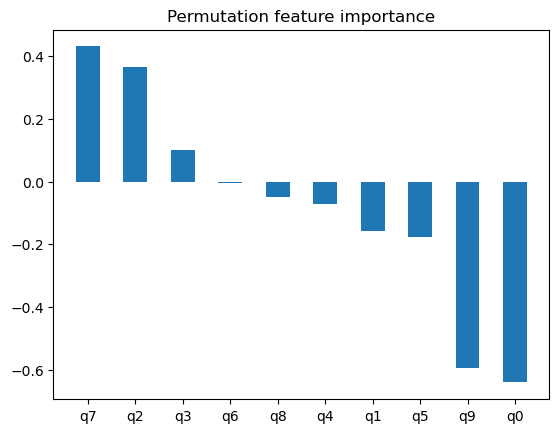

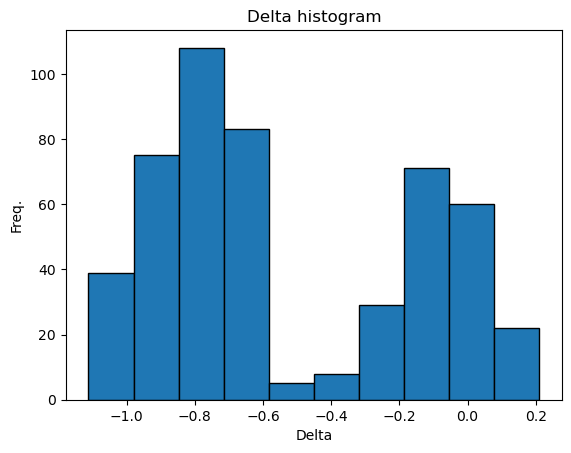

P(X > delta0)= 0.12424849699398798
0.12424849699398798 < 0.1 ?  False
Therefore, reject H0 =  False


0.12424849699398798

In [62]:
# 1) Train the model once  (already done)
# knn.fit(X_train, y_train)

seed_everything()
# Maybe you need one where u just fhuffle once, one where u shuffle many times latter one u can get a histogram and acually calculate probability.
def permutation_plot(model, X_test, y_test, iterations=5):
    f = open("model.json", "r")
    data= json.load(f)
    features = range(data["n_features_in"])
    f.close()

    # Get the regular accuracy of the model
    pred = model.predict(X_test)
    mu_control = cce(y_test, pred)


    # 2) Get feature importance
    # print(X_test, "\n")
    deltas = []
    for f, feature in enumerate(features):
        # - Randomly shuffle column for this feature

        X_test_temp = X_test.copy()

        avr_importance = 0.0
        for _ in range(iterations):
            shuffled = X_test[:, f].copy()
            np.random.shuffle(shuffled)

            X_test_temp[:, f] = shuffled
        
            # Predict accuracy on test set with the shuffled feature
            pred = model.predict(X_test_temp)
            mu_treatment = cce(y_test, pred)

            importance = mu_treatment - mu_control
            avr_importance += importance
        avr_importance /= iterations

        deltas.append(avr_importance)

    # Sort the deltas by decreasing importance
    deltas = list(enumerate(deltas))[:10]
    _deltas = sorted(deltas, key= lambda x: x[1], reverse=True)
    print(_deltas)
    n = len(deltas)
    question_number = [ "q"+str(d[0]) for d in _deltas]; 
    importance = [d[1] for d in _deltas]

    plt.title("Permutation feature importance")
    plt.bar( question_number, importance, width=0.5, label=question_number)
    plt.show()
    
    return deltas

# knn.fit(X_train, y_train)
deltas = permutation_plot(knn, X_test, y_test)



# Performs a permutation test for significance 
# feature = The index of the feature being tested
# sl = significance level
def permutation_test(model, X_test, y_test, feature, sl=0.05, iterations=500):
    f = open("model.json", "r")
    data= json.load(f)
    features = range(data["n_features_in"])
    f.close()

    # Get the regular accuracy of the model
    pred = model.predict(X_test)
    mu_control = cce(y_test, pred)


    # 2) Get feature importance


    deltas = []

    # Shuffle importance , build a histogram
    # - Randomly shuffle column for this feature
    X_test_temp = X_test.copy()
    
    for i in range(iterations):
        shuffled = X_test_temp[:, feature].copy()
        np.random.shuffle(shuffled)
        X_test_temp[:, feature] = shuffled
    
        # Predict accuracy on test set with the shuffled feature
        pred = model.predict(X_test_temp)
        mu_treatment = cce(y_test, pred)

        delta= mu_treatment - mu_control
        deltas.append(delta)
        

    
    # hist, bins = np.histogram(deltas, bins=range(10))
    plt.hist(deltas, bins=10, edgecolor="black")
    plt.xlabel("Delta")
    plt.ylabel("Freq.")
    plt.title("Delta histogram")
    plt.show() 


    deltas = np.array(deltas)[1:]
    
    # See if the the probability the improvement in the score by shuffling the column is too unlikely
    prob = np.mean( deltas > 0 ) 
    reject_h0 = prob < sl
    print("P(X > delta0)=", prob)
    print(prob, "<", sl, "? ", prob < sl)
    print("Therefore, reject H0 = ", reject_h0 )

    return prob 



# Plot the deltas
permutation_test(knn, X_test, y_test, 0, sl=0.1)






